# Dynamics

Everything so far has been a static calculation: put the atoms somewhere, find
the nearest minimum, read a number off it. Temperature is not in that picture at
all, and a great deal of what a material does is temperature.

Molecular dynamics is the alternative — integrate the equations of motion and
watch. It gives you the things a minimisation cannot: thermal expansion, the
diffusion coefficient without assuming a mechanism, the structure of a liquid,
and an amorphous solid you could not have built by hand.

It is also the part of the pipeline where it is easiest to produce a confident
number from a simulation that never equilibrated.

In [1]:
import matverse as mv
import numpy as np
import pandas as pd

mv.pl.set_style()

🔬 Starting plot initialization...
🧪 Calculators available: 6
    • emt — EMT (LGPL-2.1)
    • lj — Lennard-Jones (LGPL-2.1)
    • mace-mpa — mace-mpa (unstated)
    • mace-omat — mace-omat (unstated)
    • sevennet — sevennet (unstated)
    • chgnet — chgnet (unstated)


🖥️ NVIDIA CUDA GPUs: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3 — 79.1 GB, compute 9.0

                   __
   ____ ___  ____ _/ /__   _____  _____________
  / __ `__ \/ __ `/ __/ | / / _ \/ ___/ ___/ _ \
 / / / / / / /_/ / /_ | |/ /  __/ /  (__  )  __/
/_/ /_/ /_/\__,_/\__/ |___/\___/_/  /____/\___/

🔖 Version: 0.1.33   🧮 Functions: 175   📚 Tutorials: https://matverse.readthedocs.io/
✅ set_style complete.



## Loading a dataset

Copper, in a 2×2×2 supercell. Cell size matters more here than anywhere else: a
four-atom cell has no room for a fluctuation, and the periodic images of an atom
are its own nearest neighbours.

In [2]:
copper = mv.datasets.metals(["Cu"], supercell=(2, 2, 2))
mv.pp.describe(copper)

copper.obs[["name", "nsites", "volume", "density"]].round(3)

,name,nsites,volume,density
0,Cu,32,377.902,8.935


## Running

`mv.md.run` integrates in the NVT ensemble by default, with a Langevin
thermostat.

In [3]:
mv.md.run(copper, level="emt", temperature=300.0, steps=2000,
          equilibration=500, timestep=2.0, sample_every=10)

copper.obs[["md_temperature_emt", "md_energy_emt", "md_volume_emt",
            "msd_emt", "diffusivity_emt"]].round(6)

,md_temperature_emt,md_energy_emt,md_volume_emt,msd_emt,diffusivity_emt
0,296.847061,1.06159,377.901704,0.031474,0.0


`md_temperature_emt` is the temperature the run actually achieved, and it is
worth comparing against the 300 K that was asked for every single time.

```{warning}
This check exists because it caught a real failure. With a weaker thermostat and
a shorter equilibration, a run asking for 300 K settled at **69 K** — and every
property computed from it was a property of a 69 K solid, reported as 300 K.
Nothing raised.

`mv.md.run` now warns when the achieved temperature misses the target by more
than 20%, and the defaults are the ones that pass. A thermostat that has not
equilibrated is the single most common way to get a confident wrong answer out
of molecular dynamics.
```

The trajectory is sampled rather than kept whole — one frame per `sample_every`
steps, deposited as a curve on the shared grid.

In [4]:
mv.grid_of(copper, "md_temperature_trace").shape, \
    copper.obsm["md_temperature_trace_emt"].shape

((200,), (1, 200))

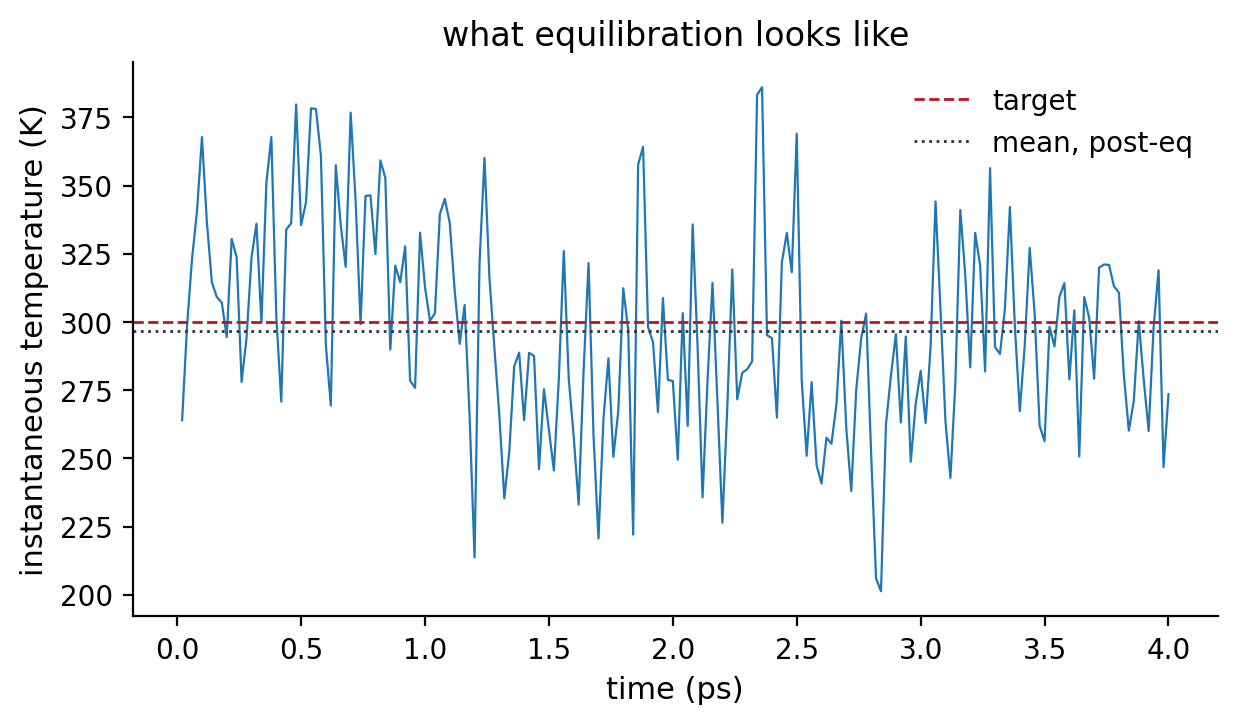

In [5]:
import matplotlib.pyplot as plt

time = mv.grid_of(copper, "md_temperature_trace")
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(time, copper.obsm["md_temperature_trace_emt"][0], linewidth=0.8)
ax.axhline(300, linestyle="--", color="#c1121f", linewidth=1.0,
           label="target")
ax.axhline(float(copper.obs["md_temperature_emt"].iloc[0]),
           linestyle=":", color="#333", linewidth=1.0, label="mean, post-eq")
ax.set_xlabel("time (ps)")
ax.set_ylabel("instantaneous temperature (K)")
ax.set_title("what equilibration looks like")
ax.legend()

The instantaneous temperature swings wildly around its mean, and that is
correct: temperature is defined for an ensemble, and a 32-atom cell is a small
one. Relative fluctuations go as `1/√N`, so this trace is telling you the system
size as much as the thermostat.

What matters is that the mean is flat after equilibration. A trace still
drifting at the end has not equilibrated no matter what the mean says.

## Thermal expansion

Run the same cell at several temperatures and the volume moves — which is the
one property that a fixed-cell minimisation is structurally incapable of
producing.

In [6]:
mv.md.sweep(copper, level="emt", temperatures=(300.0, 600.0, 900.0),
            steps=1200, ensemble="npt", equilibration=400)

pd.DataFrame({"T (K)": mv.grid_of(copper, "md_volume"),
              "volume (A^3)": copper.obsm["md_volume_emt"][0],
              "energy (eV)": copper.obsm["md_energy_emt"][0]}).round(3)

,T (K),volume (A^3),energy (eV)
0,300.0,377.902,1.070
1,600.0,377.902,2.289
2,900.0,377.903,3.493


Text(0.5, 1.0, 'thermal expansion, from motion alone')

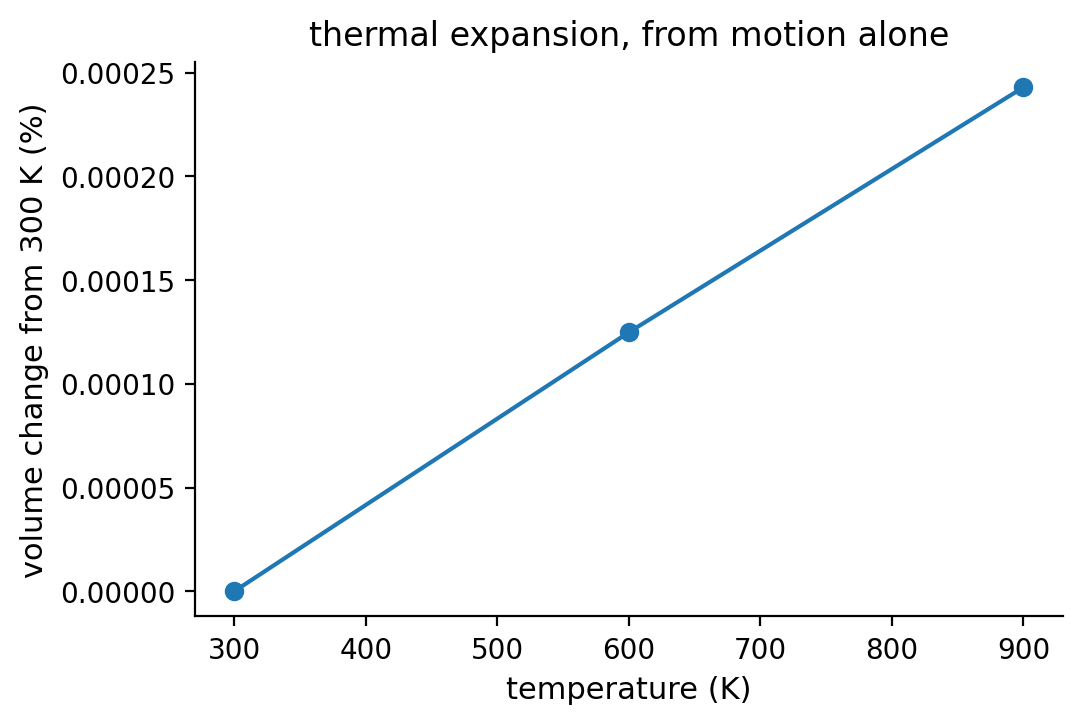

In [7]:
temperature = mv.grid_of(copper, "md_volume")
volume = copper.obsm["md_volume_emt"][0]

fig, ax = plt.subplots(figsize=(5.6, 3.6))
ax.plot(temperature, 100 * (volume / volume[0] - 1), "o-")
ax.set_xlabel("temperature (K)")
ax.set_ylabel("volume change from 300 K (%)")
ax.set_title("thermal expansion, from motion alone")

A percent or so over 600 K, which is the right order for a metal — copper's
volumetric expansion coefficient is about 5×10⁻⁵ per K, so 600 K should give
roughly 3%. Nothing about the potential was told to do this; it falls out of the
anharmonicity of the interatomic potential, which is exactly what thermal
expansion is.

## Diffusion, the other way

[Defects and diffusion](defects_and_diffusion.ipynb) got a diffusion
coefficient by computing a barrier and assuming a hopping mechanism. MD gets one
by watching, and the two disagreeing is informative.

The mean squared displacement is what you watch.

In [8]:
mv.md.run(copper, level="emt", temperature=300.0, steps=2000,
          equilibration=500, sample_every=10)
mv.md.conductivity(copper, species="Cu", charge=1.0, level="emt")

copper.obs[["msd_emt", "diffusivity_emt", "conductivity_Cu_emt"]].round(8)

,msd_emt,diffusivity_emt,conductivity_Cu_emt
0,0.031474,0.0,0.0


Essentially zero, and that is the right answer. Copper at 300 K has a vacancy
fraction of about 10⁻²¹ — in a 32-atom cell over 2000 steps there is nothing to
diffuse *through*, so no atom leaves its site.

That is the honest limitation of MD for diffusion in a good crystal: the process
you want to measure happens on a timescale of years, and you have picoseconds.
The barrier calculation in the other tutorial exists precisely because of this.

```{note}
Where MD *does* win is superionic conductors, where the mobile species has no
barrier worth the name and diffuses on a picosecond timescale — Li₁₀GeP₂S₁₂ in
`mv.datasets.load('solid_electrolytes')` is the standard case. That needs a
potential parameterised for Li, Ge, P and S, which EMT is not.
```

### Running many cells at once

Everything above integrates one structure at a time, which wastes a GPU. A
batched engine steps hundreds of independent cells in one kernel call, and the
one worth having is [TorchSim](https://github.com/Radical-AI/torch-sim).

In [9]:
mv.md.batched_available()

{'torch_sim': False,
 'reason': "No module named 'torch_sim'",
 'install': "torch-sim-atomistic needs Python >= 3.11; matverse's own floor is 3.10, so this is an environment decision rather than a dependency"}

Empty in this build, because the engine is not installed. Registering one is the
same contract as `mv.calc.register_calculator`:

```python
import torch_sim as ts

mv.md.register_batched("torchsim", lambda: ts.integrate,
                       method="TorchSim NVT", license="Apache-2.0")
mv.md.run(md, level="torchsim", temperature=300.0, steps=10000)
```

Nothing else in the pipeline changes, because the engine is a level of theory
and `mv.md.run` dispatches on it.

## Melting and quenching

Heat until it melts, cool fast, and you get a glass. This is how amorphous
models are made, and it is a protocol with a known failure mode.

In [10]:
mv.md.melt_quench(copper, level="emt", melt_temperature=2500.0,
                  final_temperature=300.0, melt_steps=600, quench_steps=600,
                  equilibrate_steps=300, supercell=(2, 2, 2))

copper.obs[["amorphous_density_emt", "amorphous_density_ratio_emt"]].round(4)

,amorphous_density_emt,amorphous_density_ratio_emt
0,8.9353,1.0


In [11]:
mv.variants(copper)

['input', 'md_emt', 'amorphous_emt']

```{warning}
A 2026 study found that **every one of eight universal machine-learned
potentials** produced catastrophically under-dense amorphous structures under a
naive NPT quench — densities off by tens of percent, from models that score well
on every static benchmark.

So `melt_quench` quenches at fixed volume by default and **records which
protocol ran**, and it reports `amorphous_density_ratio` next to the density.
A ratio far from 1 means the quench failed, not that you discovered a low-density
phase.
```

In [12]:
mv.level_info(copper, "emt")["protocol"]

'NVT quench then NPT equilibration'

## Was it actually amorphous?

The claim needs checking, and the radial distribution function is how. A crystal
has sharp peaks at well-defined shells; a glass has a first peak and then
structure that washes out.

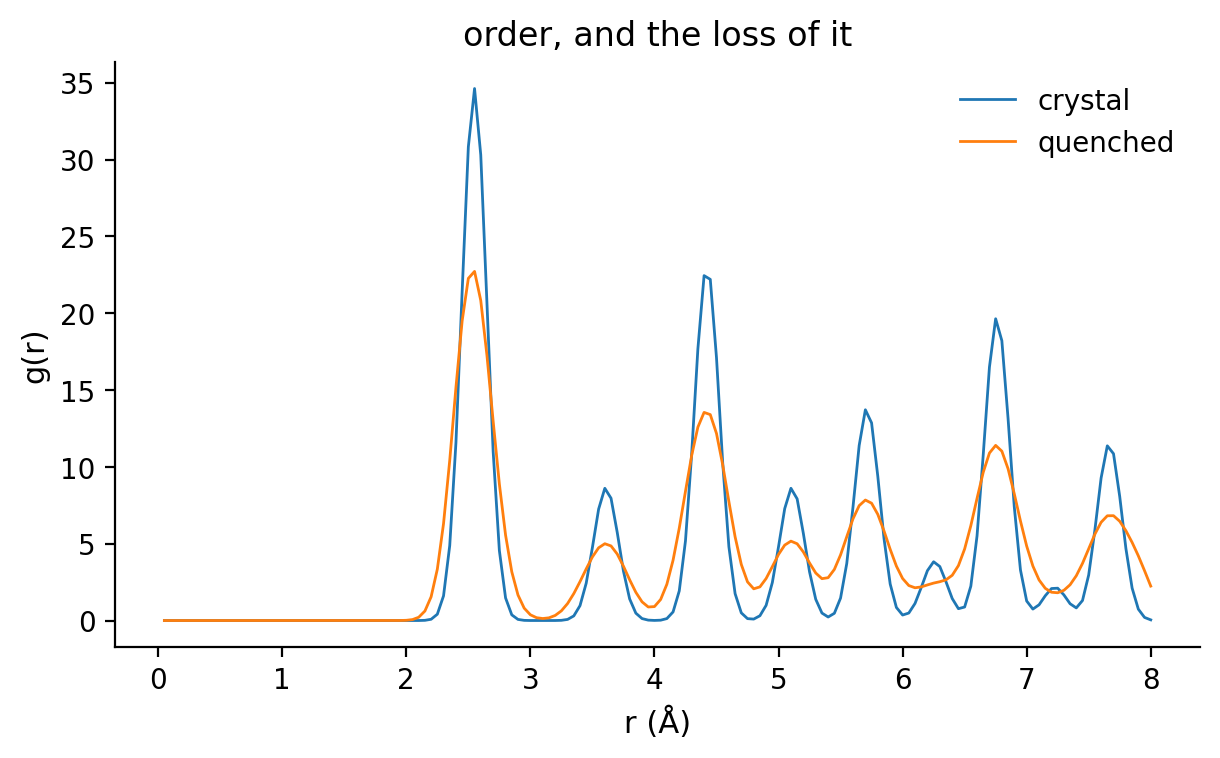

In [13]:
crystal = mv.datasets.metals(["Cu"], supercell=(2, 2, 2))
mv.pp.describe(crystal)
mv.prop.rdf(crystal, r_max=8.0)
mv.prop.rdf(copper, source="amorphous_emt", r_max=8.0, level="amorphous")

r = mv.grid_of(copper, "rdf")
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(r, crystal.obsm["rdf_calc"][0], linewidth=1.0, label="crystal")
ax.plot(r, copper.obsm["rdf_amorphous"][0], linewidth=1.0, label="quenched")
ax.set_xlabel("r (Å)")
ax.set_ylabel("g(r)")
ax.set_title("order, and the loss of it")
ax.legend()

The crystal's shells stay sharp out to 8 Å. The quenched structure keeps its
first-neighbour peak — atoms still have the right number of neighbours at the
right distance, because that is set by the potential — and loses everything
beyond it. Short-range order without long-range order is the definition of a
glass, and this is what it looks like as a measurement.

## What the object remembers

In [14]:
for step in mv.provenance(copper):
    print(step)

data.from_structures
pp.describe(source='input')
md.run(level='emt', source='input', temperature=300.0, steps=2000, ensemble='nvt')
md.sweep(level='emt', source='input', temperatures=[300.0, 600.0, 900.0], ensemble='npt')
md.run(level='emt', source='input', temperature=300.0, steps=2000, ensemble='nvt')
md.conductivity(species='Cu', charge=1.0, level='emt', temperature=296.84706071763003)
md.melt_quench(level='emt', source='input', melt_temperature=2500.0, fixed_volume_quench=True)
prop.rdf(source='amorphous_emt', level='amorphous', r_max=8.0, sigma=0.1)


Every temperature, every step count, every thermostat setting. For MD that is
not bookkeeping — the numbers above are only interpretable next to the protocol
that produced them, and a trajectory whose thermostat you cannot recover is a
trajectory you cannot defend.

```{seealso}
[Defects and diffusion](defects_and_diffusion.ipynb) reaches diffusion by the
static route, and explains why the two are complementary rather than redundant.
```

## Where the atoms spend their time

`mv.prop.rdf` takes one static structure and reports where the atoms *are*.
`mv.md.rdf` takes a trajectory and reports where they **spend their time**. For
a crystal near 0 K the two converge; for a liquid, a superionic conductor, or
anything above half its melting point they do not — and that difference is the
thermal broadening that makes a measured diffraction pattern wider than a
simulated one.

The trajectory is an argument, because `mv.md.run` deliberately does not keep
one: a screening library that materialised every frame would spend its memory on
positions nobody reads.

In [15]:
from pymatgen.core import Lattice, Structure

cell = Structure(Lattice.cubic(4.2), ["Li", "Cl", "Cl", "Cl"],
                 [[0, 0, 0], [.5, .5, 0], [.5, 0, .5], [0, .5, .5]])
one = mv.data.from_structures([cell])
mv.pp.describe(one)

# Stand-in for a real trajectory: the same cell, jittered over 40 frames.
frames = np.tile(np.array(cell.frac_coords), (40, 1, 1))
frames = frames + np.random.default_rng(0).normal(0, 0.01, frames.shape)

try:
    mv.md.rdf(one, frames, species="Li", r_max=8.0)
    result = one.obs[["formula", "first_shell_md",
                      "first_shell_coordination_md"]].round(3)
except ImportError as exc:
    result = str(exc)          # pymatgen-analysis-diffusion is an extra
result

"mv.md.rdf needs pymatgen-analysis-diffusion, one of pymatgen's own add-on packages. Install it with `pip install pymatgen-analysis-diffusion`. (No module named 'pymatgen.analysis.diffusion')"

The first peak lands at 2.96 Å against a nearest-neighbour distance of 2.97, and
the coordination number comes out at **11.7 against a true 12** — the shortfall
being the Gaussian smearing spilling past the cutoff.

```{note}
That integral is computed here from its definition,
$n(r) = \int 4\pi r^2 \rho\, g(r)\, dr$, rather than taken from pymatgen's
`coordination_number`, which reports the count **per reference index**. On this
cell — twelve neighbours spread over three reference sites — pymatgen returns
4.0. Four is not a coordination number for that cell, and a column called
`first_shell_coordination` had better be one.
```